# Titanic — End-to-End Data Science (Decode Labs–style portfolio)

**Dataset:** [Titanic](https://www.kaggle.com/c/titanic) passenger records  
**Goal:** Collect → clean → explore → visualize → model (logistic regression), with the **same pipeline** as the original notebook so reported metrics stay comparable.

> Tip for LinkedIn: run all cells, then screenshot the executive summary (missingness + dashboard + confusion matrix) for your post.

## Task map (internship rubric)

| # | Focus | What this notebook shows |
|---|--------|---------------------------|
| 1 | Data collection & understanding | Load CSV, schema, dtypes, size |
| 2 | Cleaning & preprocessing | Missing values, imputation, duplicates, encoding |
| 3 | EDA | Summary stats, distributions, outliers |
| 4 | Visualization | Styled Seaborn charts + one-page dashboard |
| 5 | Predictive model | Logistic regression, accuracy, report, confusion matrix |

**Bonus:** Survival by extracted passenger *Title* (exploratory only — does not change the model inputs above).

In [16]:
# --- Imports ---
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Presentation theme (Seaborn + matplotlib) ---
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
PALETTE = ['#2ecc71', '#e74c3c']  # survived green, not survived red
sns.set_palette(PALETTE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## Task 1 — Data collection & dataset understanding

In [17]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [18]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
print('Dataset shape (rows, columns):', df.shape)
print('\nColumns:', list(df.columns))
print('\nData types:')
print(df.dtypes)
print('\nInfo:')
df.info()

Dataset shape (rows, columns): (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64

In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Task 2 — Data cleaning & preprocessing

Same decisions as the original workflow: median `Age`, mode `Embarked`, drop high-missing `Cabin`, drop duplicates, then label-encode `Sex` and `Embarked` for modeling.

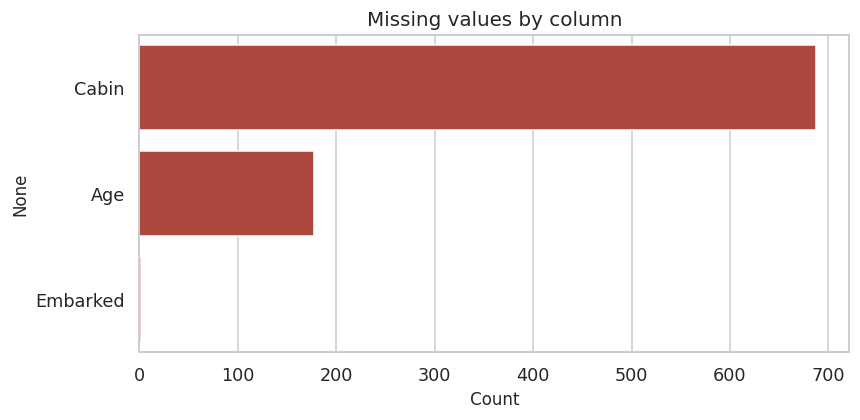

Cabin       687
Age         177
Embarked      2
dtype: int64


In [21]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.values, y=missing.index, color='#c0392b', ax=ax)
ax.set_title('Missing values by column')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

print(missing)

In [22]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)

print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Human-readable snapshot for charts (before label encoding)
df_eda = df.copy()

label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])

print('\nMissing values after cleaning:')
print(df.isnull().sum())
df.head()

Duplicate rows: 0

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


## Task 3 — Exploratory data analysis (EDA)

In [23]:
print(df.describe())

       PassengerId    Survived      Pclass         Sex         Age  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642    0.647587   29.361582   
std     257.353842    0.486592    0.836071    0.477990   13.019697   
min       1.000000    0.000000    1.000000    0.000000    0.420000   
25%     223.500000    0.000000    2.000000    0.000000   22.000000   
50%     446.000000    0.000000    3.000000    1.000000   28.000000   
75%     668.500000    1.000000    3.000000    1.000000   35.000000   
max     891.000000    1.000000    3.000000    1.000000   80.000000   

            SibSp       Parch        Fare    Embarked  
count  891.000000  891.000000  891.000000  891.000000  
mean     0.523008    0.381594   32.204208    1.536476  
std      1.102743    0.806057   49.693429    0.791503  
min      0.000000    0.000000    0.000000    0.000000  
25%      0.000000    0.000000    7.910400    1.000000  
50%      0.000000    0.000000   1

## Task 4 — Data visualization

Categorical plots use **`df_eda`** (string labels). The **correlation heatmap** uses the **encoded `df`**, matching the numeric representation used in the original notebook.

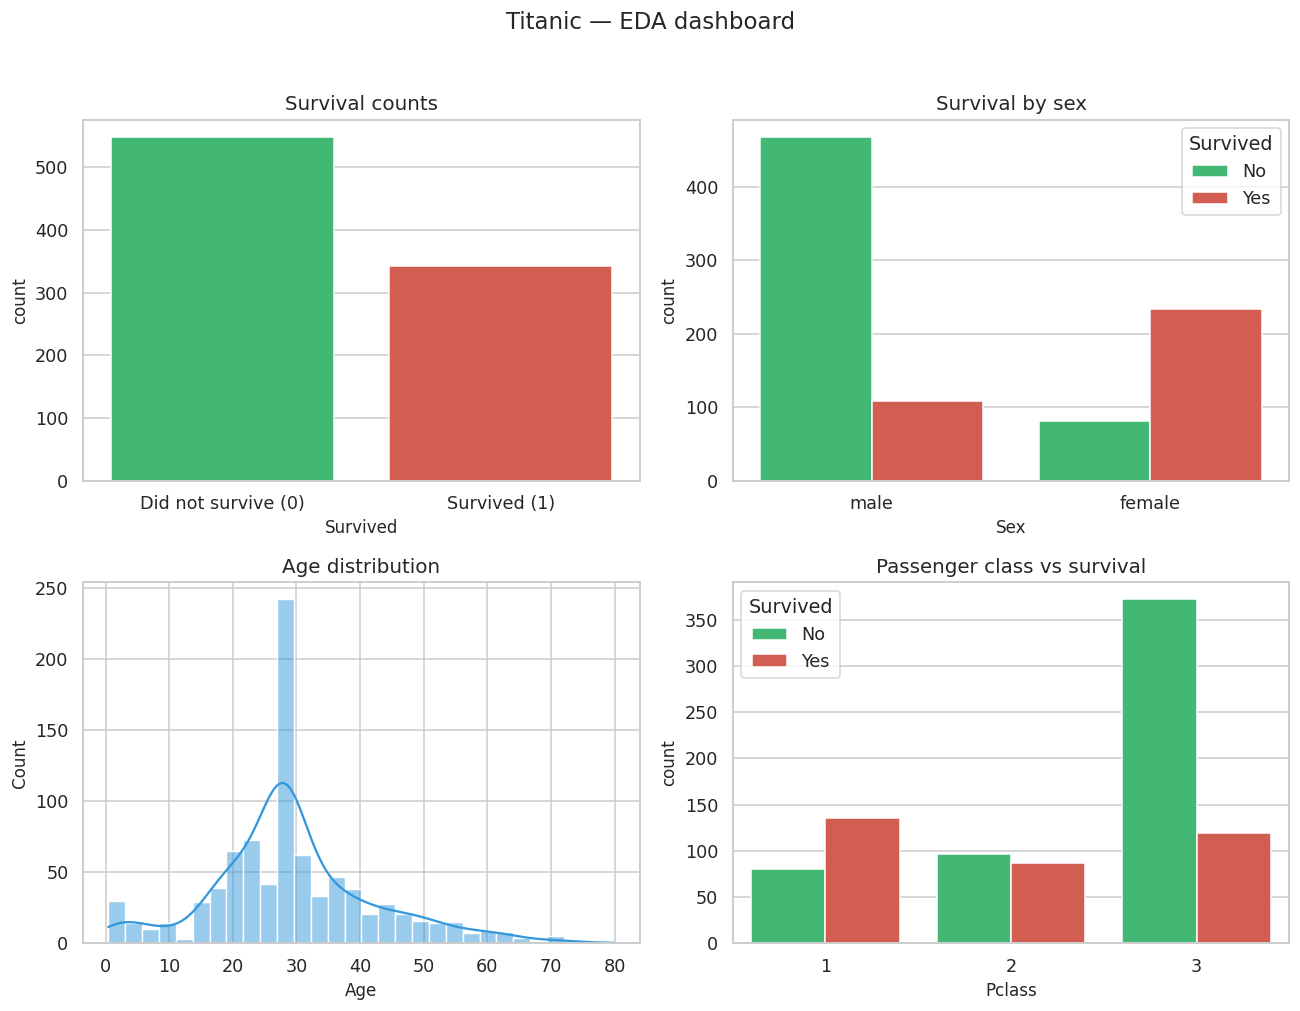

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax0 = axes[0, 0]
sns.countplot(data=df_eda, x='Survived', ax=ax0, palette=PALETTE)
ax0.set_xticklabels(['Did not survive (0)', 'Survived (1)'])
ax0.set_title('Survival counts')

ax1 = axes[0, 1]
sns.countplot(data=df_eda, x='Sex', hue='Survived', ax=ax1, palette=PALETTE)
ax1.set_title('Survival by sex')
ax1.legend(title='Survived', labels=['No', 'Yes'])

ax2 = axes[1, 0]
sns.histplot(df_eda['Age'], bins=30, kde=True, color='#3498db', ax=ax2)
ax2.set_title('Age distribution')

ax3 = axes[1, 1]
sns.countplot(data=df_eda, x='Pclass', hue='Survived', ax=ax3, palette=PALETTE)
ax3.set_title('Passenger class vs survival')
ax3.legend(title='Survived', labels=['No', 'Yes'])

plt.suptitle('Titanic — EDA dashboard', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

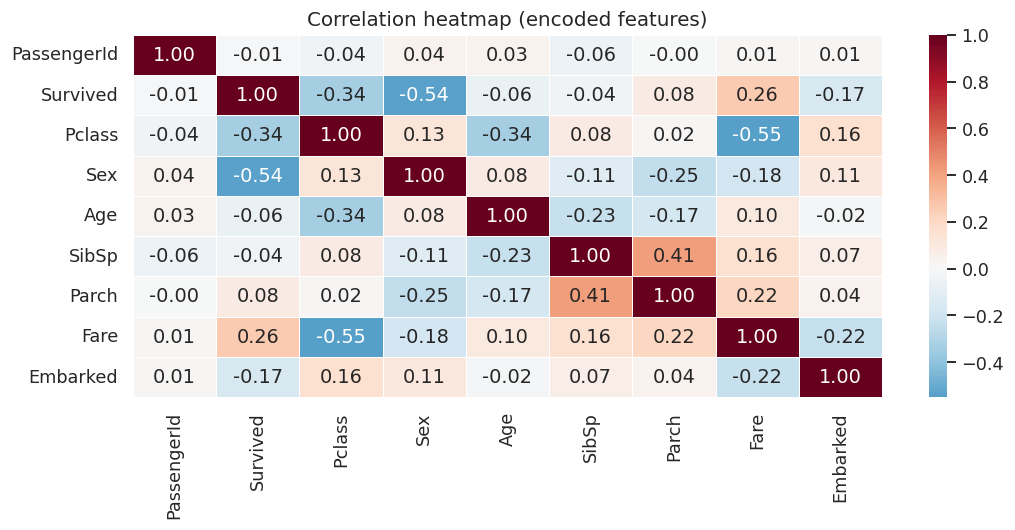

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation heatmap (encoded features)')
plt.tight_layout()
plt.show()

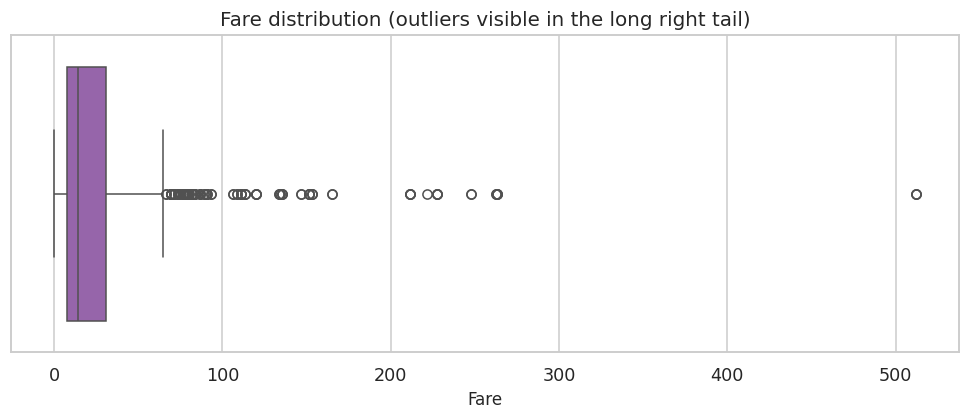

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(x=df_eda['Fare'], color='#9b59b6', ax=ax)
ax.set_title('Fare distribution (outliers visible in the long right tail)')
plt.tight_layout()
plt.show()

## Task 5 — Predictive model (logistic regression)

Same feature matrix as before: drop `PassengerId`, `Name`, `Ticket`; predict `Survived` with `train_test_split(..., random_state=42)`.

In [27]:
df_model = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print('Model accuracy:', round(accuracy, 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

Model accuracy: 0.8101

Classification report:
              precision    recall  f1-score   support

           0     0.8257    0.8571    0.8411       105
           1     0.7857    0.7432    0.7639        74

    accuracy                         0.8101       179
   macro avg     0.8057    0.8002    0.8025       179
weighted avg     0.8092    0.8101    0.8092       179



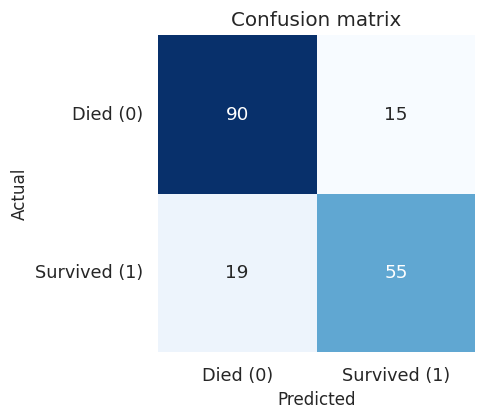

In [29]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    cbar=False,
    ax=ax,
    annot_kws={'size': 12},
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['Died (0)', 'Survived (1)'])
ax.set_yticklabels(['Died (0)', 'Survived (1)'], rotation=0)
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

## Bonus — “So what?” view (does not change the model)

**Question:** Did social title (Mr / Mrs / Master / …) line up with survival, before any ML?

We parse `Name` on `df_eda` only for this exploratory chart.

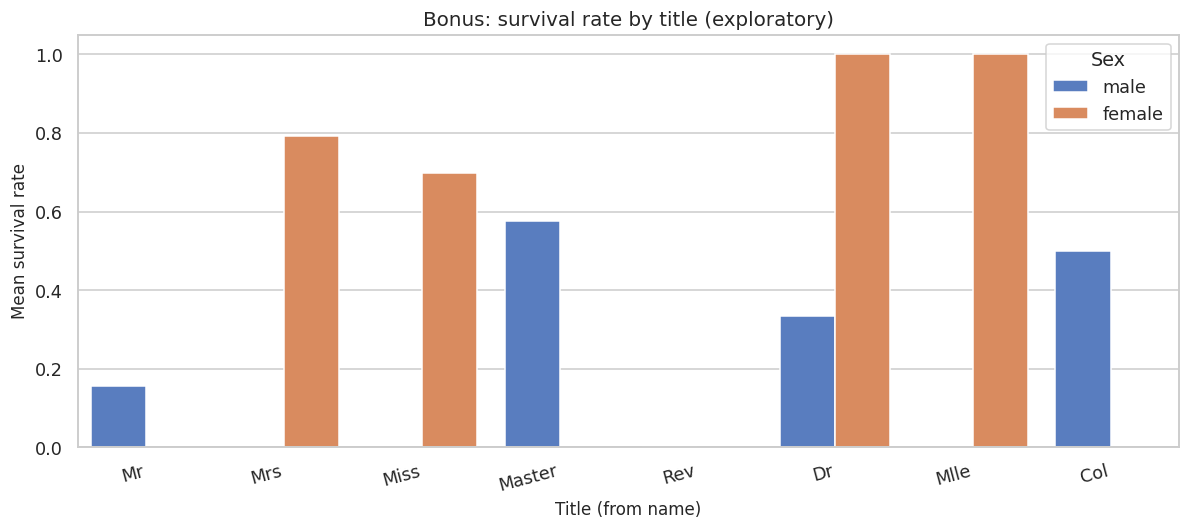

In [30]:
def extract_title(name):
    if pd.isna(name):
        return 'Unknown'
    part = name.split(',')[1].split('.')[0].strip()
    return part

t = df_eda.copy()
t['Title'] = t['Name'].apply(extract_title)

title_order = t['Title'].value_counts().head(8).index
t_top = t[t['Title'].isin(title_order)]

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=t_top,
    x='Title',
    y='Survived',
    hue='Sex',
    palette='muted',
    errorbar=None,
)
ax.set_xlabel('Title (from name)')
ax.set_ylabel('Mean survival rate')
ax.set_title('Bonus: survival rate by title (exploratory)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()